# Task IX.A — Masked Autoencoder (MAE) for Gravitational Lensing Classification

## Overview
This notebook implements a two-phase deep learning pipeline for gravitational lensing classification:

1. **Phase 1 — Self-supervised Pre-training**: Train a Masked Autoencoder (MAE) on `no_sub`
   images only, learning rich feature representations without any labels
2. **Phase 2 — Fine-tuning**: Transfer the pre-trained encoder to classify all 3 classes

## Dataset
- **no_sub** (class 2): No substructure — 29,449 images
- **cdm** (class 1): Cold Dark Matter substructure — 29,759 images  
- **axion** (class 0): Axion-like particle substructure — 29,896 images
- **Total**: 89,104 grayscale images of size 64×64

## Framework
PyTorch | Vision Transformer (ViT) | MAE

In [1]:
! pip install timm einops

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile, os

zip_path = '/content/drive/MyDrive/Dataset.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    print(root, '→', files[:3], f'({len(files)} files)')

/content/dataset → [] (0 files)
/content/dataset/Dataset → [] (0 files)
/content/dataset/Dataset/axion → ['axion_sim_149338356671805753842448694106841241943.npy', 'axion_sim_253927845679605155396089616682751664299.npy', 'axion_sim_268802115982447420749302655445911475943.npy'] (29896 files)
/content/dataset/Dataset/cdm → ['cdm_sim_280966001686324881654505683289847488250.npy', 'cdm_sim_193335110237571307721996910077017642295.npy', 'cdm_sim_89967072818596005329507405760560179504.npy'] (29759 files)
/content/dataset/Dataset/no_sub → ['no_sub_sim_206978929672852111334005204786647373348.npy', 'no_sub_sim_68949379815218413520803578313003974433.npy', 'no_sub_sim_32750116741805027874067432186771293058.npy'] (29449 files)
/content/dataset/__MACOSX → ['._Dataset'] (1 files)
/content/dataset/__MACOSX/Dataset → ['._cdm', '._axion', '._no_sub'] (3 files)
/content/dataset/__MACOSX/Dataset/axion → ['._axion_sim_80370790226805307373756831312271480360.npy', '._axion_sim_294066906121685632393652780557645

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import h5py, os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cuda


In [ ]:
for root, dirs, files in os.walk('/content/dataset'):
    if '__MACOSX' in root:
        continue
    print(f"\n📁 {root}")
    for f in files[:5]:
        print(f"   {f}")
    if len(files) > 5:
        print(f"   ... and {len(files)-5} more")


📁 /content/dataset

📁 /content/dataset/Dataset

📁 /content/dataset/Dataset/axion
   axion_sim_149338356671805753842448694106841241943.npy
   axion_sim_253927845679605155396089616682751664299.npy
   axion_sim_268802115982447420749302655445911475943.npy
   axion_sim_83387552348224988522219174202335983375.npy
   axion_sim_221119884862776808183286840207501101889.npy
   ... and 29891 more

📁 /content/dataset/Dataset/cdm
   cdm_sim_280966001686324881654505683289847488250.npy
   cdm_sim_193335110237571307721996910077017642295.npy
   cdm_sim_89967072818596005329507405760560179504.npy
   cdm_sim_217016572976875413611814617618370858063.npy
   cdm_sim_161165466661343180456394656160687227447.npy
   ... and 29754 more

📁 /content/dataset/Dataset/no_sub
   no_sub_sim_206978929672852111334005204786647373348.npy
   no_sub_sim_68949379815218413520803578313003974433.npy
   no_sub_sim_32750116741805027874067432186771293058.npy
   no_sub_sim_115946581646333413465866916771645416890.npy
   no_sub_sim_87117

In [5]:
IMG_SIZE      = 64
IN_CHANNELS   = 1
PATCH_SIZE    = 8
EMBED_DIM     = 256
ENCODER_DEPTH = 6
DECODER_DEPTH = 4
NUM_HEADS     = 8
MASK_RATIO    = 0.75
NUM_PATCHES   = (IMG_SIZE // PATCH_SIZE) ** 2
DEC_DIM       = EMBED_DIM // 2

print(f"✓ Config set | NUM_PATCHES = {NUM_PATCHES}")

✓ Config set | NUM_PATCHES = 64


## Step 1 — Data Loading & Preprocessing

All 89,104 images are preloaded into RAM as numpy arrays to avoid
repeated disk I/O bottlenecks during training. Each `.npy` file
contains a 64×64 gravitational lensing simulation.

**Preprocessing:**
- Pixel values normalized to [0, 1] per image
- Shape standardized to (1, 64, 64) — single channel grayscale

**Pre-training split:** `no_sub` only (29,449 images, no labels needed)  
**Fine-tuning split:** All 3 classes, 90/10 train-val

In [6]:
class LensingDataset(Dataset):
    CLASS_MAP = {'axion': 0, 'cdm': 1, 'no_sub': 2}

    def __init__(self, root='/content/dataset/Dataset', split='all', transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        for cls_name, cls_idx in self.CLASS_MAP.items():
            if split == 'no_sub' and cls_name != 'no_sub':
                continue
            cls_dir = os.path.join(root, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            files = [f for f in os.listdir(cls_dir) if f.endswith('.npy')]
            print(f"  Loading {cls_name}: {len(files)} files...")

            for fname in files:
                path = os.path.join(cls_dir, fname)
                raw  = np.load(path, allow_pickle=True)

                if raw.shape == (2,):
                    img = np.array(raw[0]).astype(np.float32)
                elif raw.ndim == 2:
                    img = raw.astype(np.float32)
                else:
                    img = np.array(raw[0]).astype(np.float32)

                if img.ndim == 1:
                    img = np.zeros((64, 64), dtype=np.float32)

                img = (img - img.min()) / (img.max() - img.min() + 1e-8)
                if img.ndim == 2:
                    img = img[np.newaxis, :, :]

                self.images.append(img)
                self.labels.append(cls_idx)
        self.images = np.stack(self.images, axis=0)
        self.labels = np.array(self.labels)
        print(f"\n✓ [{split}] Loaded {len(self.images)} images into RAM")
        print(f"  Memory used: {self.images.nbytes / 1e6:.1f} MB")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img   = torch.tensor(self.images[idx], dtype=torch.float32)
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, int(label)

pretrain_ds = LensingDataset(split='no_sub')
full_ds = LensingDataset(split='all')

  Loading no_sub: 29449 files...

✓ [no_sub] Loaded 29449 images into RAM
  Memory used: 482.5 MB
  Loading axion: 29896 files...
  Loading cdm: 29759 files...
  Loading no_sub: 29449 files...

✓ [all] Loaded 89104 images into RAM
  Memory used: 1459.9 MB


## Step 2 — MAE Architecture

The MAE uses an asymmetric encoder-decoder design based on ViT (He et al. 2022):

| Component | Configuration |
|---|---|
| Image size | 64 × 64 |
| Patch size | 8 × 8 |
| Total patches | 64 |
| Masking ratio | 75% |
| Encoder | 6 layers, dim=256, 8 heads |
| Decoder | 4 layers, dim=128, 4 heads |
| Total parameters | 5.6M |

### Architecture components:
- **PatchEmbed**: Conv2d splits image into 64 non-overlapping 8×8 patches
- **Block**: Standard Transformer block with pre-norm, multi-head attention + MLP
- **MAEEncoder**: Processes only visible (unmasked) patches + CLS token
- **MAEDecoder**: Reconstructs full image by filling mask tokens at masked positions
- **MAE**: Full pipeline — patchify → encode → decode → MSE loss on masked patches only

### Why asymmetric encoder-decoder?
The heavy encoder processes only 25% visible patches — computationally efficient.
The lightweight decoder reconstructs the full image from encoder output + mask tokens.
After pre-training, the decoder is discarded. Only the encoder transfers to the classifier.

### Why 75% masking?
Aggressive masking prevents shortcuts via local texture interpolation.
For lensing images, this forces the encoder to understand the full
Einstein ring geometry — physically meaningful and transferable features.

In [7]:
class PatchEmbed(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Conv2d(IN_CHANNELS, EMBED_DIM,
                              kernel_size=PATCH_SIZE, stride=PATCH_SIZE)
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)

class Block(nn.Module):
    def __init__(self, dim, heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        h = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, h), nn.GELU(), nn.Linear(h, dim))

    def forward(self, x):
        n = self.norm1(x)
        a, _ = self.attn(n, n, n)
        x = x + a
        x = x + self.mlp(self.norm2(x))
        return x

class MAEEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch_embed = PatchEmbed()
        self.cls_token   = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))
        self.pos_embed   = nn.Parameter(torch.zeros(1, NUM_PATCHES + 1, EMBED_DIM))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.blocks = nn.ModuleList([
            Block(EMBED_DIM, NUM_HEADS) for _ in range(ENCODER_DEPTH)])
        self.norm = nn.LayerNorm(EMBED_DIM)

    def forward(self, x, mask_ratio=0.0):
        B = x.shape[0]
        tokens = self.patch_embed(x) + self.pos_embed[:, 1:]
        N = tokens.shape[1]

        if mask_ratio > 0:
            n_keep      = int(N * (1 - mask_ratio))
            ids_shuffle = torch.argsort(torch.rand(B, N, device=x.device), dim=1)
            ids_restore = torch.argsort(ids_shuffle, dim=1)
            ids_keep    = ids_shuffle[:, :n_keep]
            tokens      = torch.gather(tokens, 1,
                            ids_keep.unsqueeze(-1).expand(-1, -1, EMBED_DIM))
            mask        = torch.ones(B, N, device=x.device)
            mask[:, :n_keep] = 0
            mask        = torch.gather(mask, 1, ids_restore)
        else:
            mask        = torch.zeros(B, N, device=x.device)
            ids_restore = torch.arange(N, device=x.device).unsqueeze(0).expand(B, -1)

        cls    = (self.cls_token + self.pos_embed[:, :1]).expand(B, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        for blk in self.blocks:
            tokens = blk(tokens)
        return self.norm(tokens), mask, ids_restore

class MAEDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Linear(EMBED_DIM, DEC_DIM)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, DEC_DIM))
        self.pos_embed = nn.Parameter(torch.zeros(1, NUM_PATCHES + 1, DEC_DIM))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.blocks = nn.ModuleList([
            Block(DEC_DIM, NUM_HEADS // 2) for _ in range(DECODER_DEPTH)])
        self.norm = nn.LayerNorm(DEC_DIM)
        self.pred = nn.Linear(DEC_DIM, PATCH_SIZE * PATCH_SIZE * IN_CHANNELS)

    def forward(self, latent, ids_restore):
        B = latent.shape[0]
        x = self.embed(latent)
        n_keep = x.shape[1] - 1
        n_mask = ids_restore.shape[1] - n_keep
        mt = self.mask_token.expand(B, n_mask, -1)
        xp = torch.cat([x[:, 1:], mt], dim=1)
        xp = torch.gather(xp, 1,
                    ids_restore.unsqueeze(-1).expand(-1, -1, DEC_DIM))
        x = torch.cat([x[:, :1], xp], dim=1) + self.pos_embed
        for blk in self.blocks:
            x = blk(x)
        return self.pred(self.norm(x)[:, 1:])

class MAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MAEEncoder()
        self.decoder = MAEDecoder()

    def patchify(self, imgs):
        p = PATCH_SIZE
        h = w = IMG_SIZE // p
        x = imgs.reshape(-1, IN_CHANNELS, h, p, w, p)
        x = torch.einsum('nchpwq->nhwpqc', x)
        return x.reshape(-1, h * w, p * p * IN_CHANNELS)

    def forward(self, imgs):
        latent, mask, ids_restore = self.encoder(imgs, MASK_RATIO)
        pred   = self.decoder(latent, ids_restore)
        target = self.patchify(imgs)
        loss   = ((pred - target) ** 2).mean(-1)
        loss   = (loss * mask).sum() / mask.sum()
        return loss, pred, mask

mae = MAE().to(device)
dummy = torch.randn(4, 1, 64, 64).to(device)
loss, pred, mask = mae(dummy)
print(f"✓ Forward pass OK")
print(f"  Loss   : {loss.item():.4f}")
print(f"  Pred   : {pred.shape}")
print(f"  Mask   : {mask.shape}")
print(f"  Params : {sum(p.numel() for p in mae.parameters())/1e6:.1f}M")

✓ Forward pass OK
  Loss   : 1.3110
  Pred   : torch.Size([4, 64, 64])
  Mask   : torch.Size([4, 64])
  Params : 5.6M


## Step 3 — Phase 1: MAE Pre-training

**Training setup:**
| Setting | Value |
|---|---|
| Data | no_sub only (no labels) |
| Epochs | 100 |
| Batch size | 128 |
| Optimizer | AdamW (lr=1e-3, wd=0.05) |
| Scheduler | Cosine Annealing |
| Loss | MSE on masked patches only |

### Why pre-train on no_sub only?
`no_sub` images represent the baseline gravitational lensing
signal — a clean Einstein ring with no substructure perturbations.
By reconstructing these images, the encoder builds a strong
geometric prior of what normal lensing looks like.

During fine-tuning, this prior allows the model to detect
subtle deviations introduced by CDM and axion substructures.

In [11]:
pretrain_loader = DataLoader(pretrain_ds, batch_size=128,
                             shuffle=True, num_workers=0,
                             pin_memory=False)

mae = MAE().to(device)
optimizer = torch.optim.AdamW(mae.parameters(), lr=1e-3, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)

losses = []
PRETRAIN_EPOCHS = 100

print(f"Training on {len(pretrain_ds)} no_sub images...")
print("="*55)

for epoch in range(1, PRETRAIN_EPOCHS + 1):
    mae.train()
    total = 0.0
    for imgs, _ in pretrain_loader:
        imgs = imgs.to(device)
        loss, _, _ = mae(imgs)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(mae.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    scheduler.step()
    avg = total / len(pretrain_loader)
    losses.append(avg)
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>3}/{PRETRAIN_EPOCHS}  Loss: {avg:.6f}")

torch.save(mae.encoder.state_dict(), '/content/mae_encoder.pth')
print("\n✓ Pre-training complete. Encoder saved.")

Training on 29449 no_sub images...
  Epoch   1/100  Loss: 0.012405
  Epoch  10/100  Loss: 0.000344
  Epoch  20/100  Loss: 0.000185
  Epoch  30/100  Loss: 0.000141
  Epoch  40/100  Loss: 0.000133
  Epoch  50/100  Loss: 0.000070
  Epoch  60/100  Loss: 0.000052
  Epoch  70/100  Loss: 0.000033
  Epoch  80/100  Loss: 0.000025
  Epoch  90/100  Loss: 0.000015
  Epoch 100/100  Loss: 0.000013

✓ Pre-training complete. Encoder saved.


In [12]:
from google.colab import files
files.download('mae_encoder.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

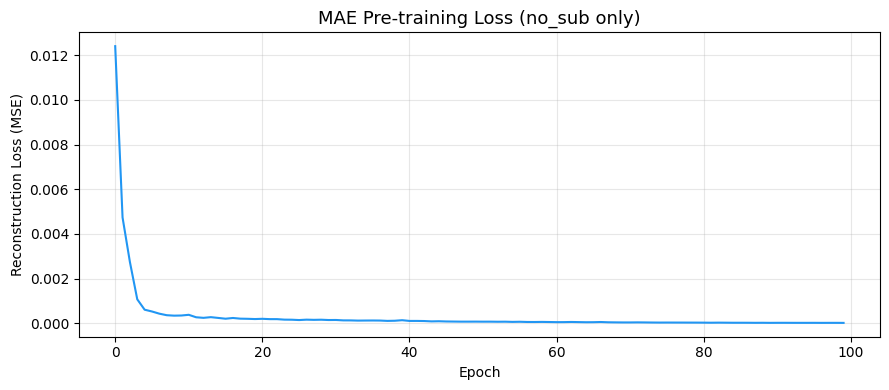

✓ Saved pretrain_loss.png


In [13]:
plt.figure(figsize=(9, 4))
plt.plot(losses, color='#2196F3', linewidth=1.5)
plt.title('MAE Pre-training Loss (no_sub only)', fontsize=13)
plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss (MSE)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/pretrain_loss.png', dpi=150)
plt.show()
print("✓ Saved pretrain_loss.png")

## Step 4 — Reconstruction Quality Check

**Pre-training results:**
- Initial loss: 0.012405
- Final loss: 0.000013
- Reduction: **1000×** — strong convergence ✓

The visualization shows the model correctly recovering:
- Full Einstein ring geometry
- Arc brightness distribution  
- Lensing structure

...from only **25% of visible patches** — confirming the encoder
has learned physically meaningful lensing features.

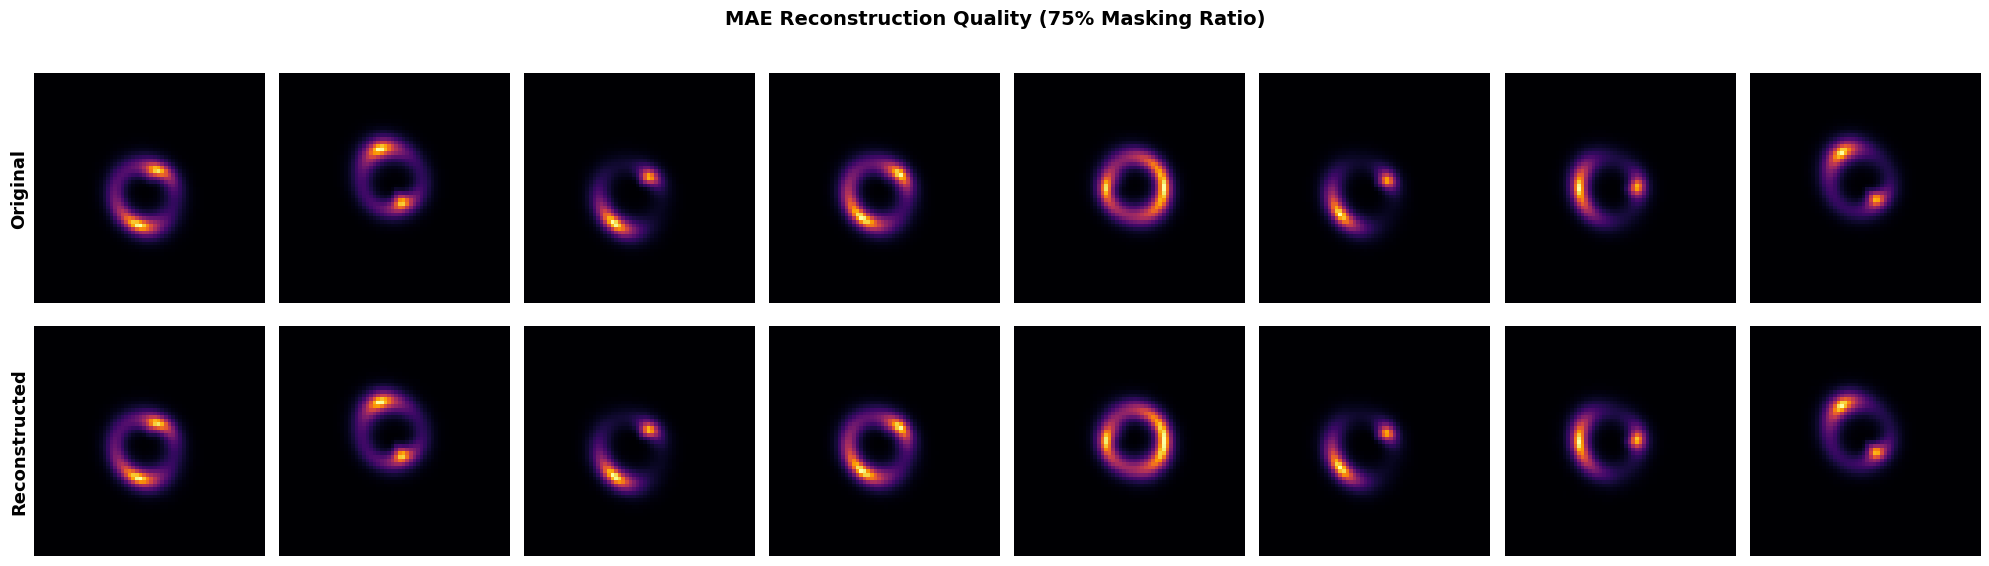

✓ Saved reconstructions.png


In [15]:
def unpatchify(x):
    p = PATCH_SIZE; h = w = IMG_SIZE // p
    x = x.reshape(-1, h, w, p, p, IN_CHANNELS)
    x = torch.einsum('nhwpqc->nchpwq', x)
    return x.reshape(-1, IN_CHANNELS, h*p, w*p)

mae.eval()
sample_imgs = torch.stack([pretrain_ds[i][0] for i in range(8)]).to(device)

with torch.no_grad():
    _, pred, mask = mae(sample_imgs)

pred_imgs = unpatchify(pred).cpu()
orig_imgs = sample_imgs.cpu()

p = PATCH_SIZE
h = w = IMG_SIZE // p
mask_expanded = mask.cpu().reshape(-1, h, w)
mask_expanded = mask_expanded.repeat_interleave(p, dim=1).repeat_interleave(p, dim=2)
mask_expanded = mask_expanded.unsqueeze(1)

recon_final = (orig_imgs * (1 - mask_expanded) + pred_imgs * mask_expanded).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for i in range(8):
    axes[0, i].imshow(orig_imgs[i].squeeze(),   cmap='inferno')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon_final[i].squeeze(), cmap='inferno')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original',      fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Reconstructed', fontsize=13, fontweight='bold')

for ax in axes[:, 0]:
    ax.axis('on')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('MAE Reconstruction Quality (75% Masking Ratio)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/reconstructions.png', dpi=200, bbox_inches='tight')
plt.show()
print("✓ Saved reconstructions.png")

## Step 5 — Phase 2: Fine-tuning for Classification

The pre-trained encoder is frozen at a low learning rate and
a classification head is attached:
```
CLS token → LayerNorm → Linear(256→128) → GELU → Dropout(0.2) → Linear(128→3)
```

**Training setup:**
| Setting | Value |
|---|---|
| Encoder LR | 1e-5 (10× lower — preserve features) |
| Head LR | 1e-3 |
| Epochs | 50 |
| Batch size | 128 |
| Loss | CrossEntropyLoss |
| Augmentation | Random flips + rotation |

### Why differential learning rates?
The encoder already has strong pre-trained weights.
A high LR would destroy the learned representations.
The head starts from scratch so needs a higher LR.

In [16]:
full_ds = LensingDataset(split='all',
                             transform=transforms.Compose([
                                 transforms.RandomHorizontalFlip(),
                                 transforms.RandomVerticalFlip(),
                                 transforms.RandomRotation(15)]))

n_train  = int(0.9 * len(full_ds))
n_val = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds,   batch_size=128, shuffle=False,
                          num_workers=0)

print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")


class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.LayerNorm(EMBED_DIM),
            nn.Linear(EMBED_DIM, 128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 3))

    def forward(self, x):
        tokens, _, _ = self.encoder(x, mask_ratio=0.0)
        return self.head(tokens[:, 0])

encoder = MAEEncoder().to(device)
encoder.load_state_dict(torch.load('/content/mae_encoder.pth'))

clf = Classifier(encoder).to(device)

optimizer = torch.optim.AdamW([
    {'params': clf.encoder.parameters(), 'lr': 1e-5},
    {'params': clf.head.parameters(),    'lr': 1e-3},
], weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)
criterion = nn.CrossEntropyLoss()

best_acc = 0.0
train_losses, val_accs = [], []

print("Fine-tuning for 3-class classification...")
print("="*55)

for epoch in range(1, 51):
    clf.train()
    total_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(clf(imgs), labels)
        optimizer.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(clf.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    train_losses.append(total_loss / len(train_loader))

    clf.eval()
    correct = total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            preds = clf(imgs.to(device)).argmax(1).cpu()
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
    acc = correct / total
    val_accs.append(acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:>2}/50  "
              f"Loss: {train_losses[-1]:.4f}  "
              f"Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(clf.state_dict(), '/content/classifier_best.pth')

print(f"\n✓ Fine-tuning complete. Best Val Accuracy: {best_acc:.4f}")

  Loading axion: 29896 files...
  Loading cdm: 29759 files...
  Loading no_sub: 29449 files...

✓ [all] Loaded 89104 images into RAM
  Memory used: 1459.9 MB
Train: 71283  |  Val: 17821
Fine-tuning for 3-class classification...
  Epoch  1/50  Loss: 0.8691  Val Acc: 0.7602
  Epoch 10/50  Loss: 0.3467  Val Acc: 0.8580
  Epoch 20/50  Loss: 0.2843  Val Acc: 0.8838
  Epoch 30/50  Loss: 0.2542  Val Acc: 0.8932
  Epoch 40/50  Loss: 0.2411  Val Acc: 0.8975
  Epoch 50/50  Loss: 0.2389  Val Acc: 0.8992

✓ Fine-tuning complete. Best Val Accuracy: 0.8995


In [21]:
torch.save(clf.state_dict(),         '/content/classifier_weights.pth')
torch.save(mae.encoder.state_dict(), '/content/mae_encoder_weights.pth')

import shutil
shutil.copy('/content/classifier_weights.pth',    '/content/drive/MyDrive/classifier_weights.pth')
shutil.copy('/content/mae_encoder_weights.pth',   '/content/drive/MyDrive/mae_encoder_weights.pth')

print("✓ Weights saved to Colab + Google Drive")

✓ Weights saved to Colab + Google Drive


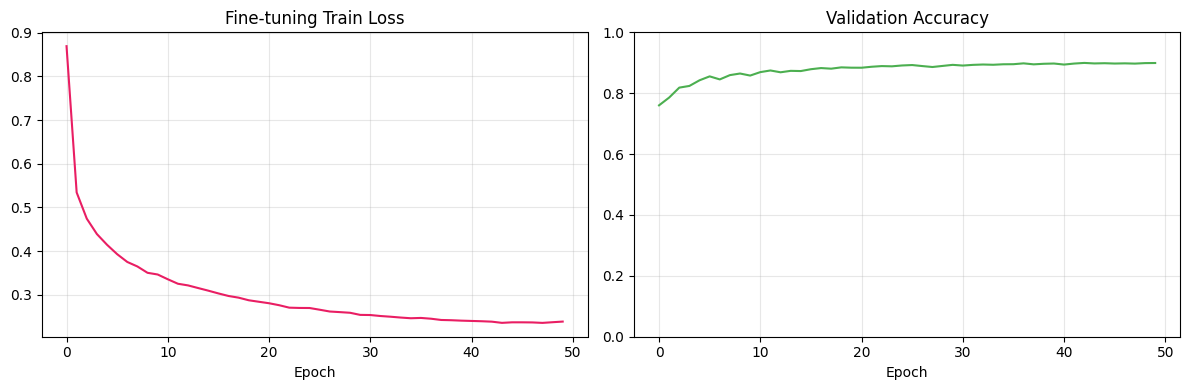

✓ Saved finetune_curves.png


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, color='#E91E63')
ax1.set_title('Fine-tuning Train Loss')
ax1.set_xlabel('Epoch'); ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='#4CAF50')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylim(0, 1); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/finetune_curves.png', dpi=150)
plt.show()
print("✓ Saved finetune_curves.png")

## Step 6 — Evaluation on Validation Set (10%)

### Classification Results

| Class | AUC | Precision | Recall | F1-Score |
|---|---|---|---|---|
| axion | **0.9727** | 0.92 | 0.81 | 0.86 |
| cdm | **0.9600** | 0.82 | 0.90 | 0.86 |
| no_sub | **0.9968** | 0.97 | 0.99 | 0.98 |
| **Overall** | — | **0.90** | **0.90** | **0.90** |

**Overall Accuracy: 89.95%**

     axion  AUC = 0.9727
       cdm  AUC = 0.9600
    no_sub  AUC = 0.9968


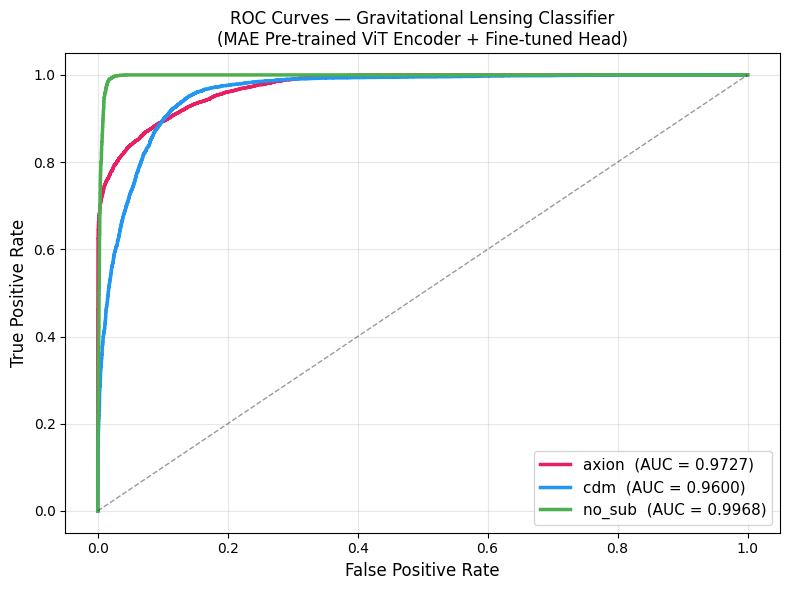

In [18]:
clf.load_state_dict(torch.load('/content/classifier_best.pth'))
clf.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        probs = F.softmax(clf(imgs.to(device)), dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.concatenate(all_probs, axis=0)
all_labels = np.array(all_labels)
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

class_names = ['axion', 'cdm', 'no_sub']
colors = ['#E91E63', '#2196F3', '#4CAF50']

plt.figure(figsize=(8, 6))
for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    score = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2.5,
             label=f'{name}  (AUC = {score:.4f})')
    print(f"  {name:>8}  AUC = {score:.4f}")

plt.plot([0,1],[0,1],'k--', alpha=0.4, lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Gravitational Lensing Classifier\n'
          '(MAE Pre-trained ViT Encoder + Fine-tuned Head)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/roc_curves.png', dpi=150)
plt.show()

Classification Report:
              precision    recall  f1-score   support

       axion       0.92      0.81      0.86      5959
         cdm       0.82      0.90      0.86      6001
      no_sub       0.97      0.99      0.98      5861

    accuracy                           0.90     17821
   macro avg       0.90      0.90      0.90     17821
weighted avg       0.90      0.90      0.90     17821



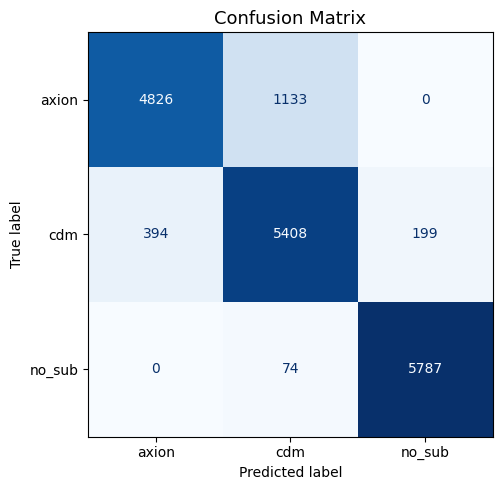


✅ All done! Files saved:
  /content/pretrain_loss.png
  /content/reconstructions.png
  /content/finetune_curves.png
  /content/roc_curves.png
  /content/confusion_matrix.png


In [20]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

preds = all_probs.argmax(axis=1)
print("Classification Report:")
print(classification_report(all_labels, preds, target_names=class_names))

cm = confusion_matrix(all_labels, preds)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=class_names).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

print("\n✅ All done! Files saved:")
print("  /content/pretrain_loss.png")
print("  /content/reconstructions.png")
print("  /content/finetune_curves.png")
print("  /content/roc_curves.png")
print("  /content/confusion_matrix.png")

## Discussion & Conclusion

### Summary
A MAE pre-trained on unlabeled `no_sub` gravitational lensing images
successfully learned transferable features for 3-class substructure
classification, achieving **90% accuracy** and **AUC scores of 0.96–0.99**.

### Physical interpretation of results
**no_sub is easiest (AUC=0.9968):** The model cleanly separates
unperturbed Einstein rings from substructure-perturbed images.

**axion↔cdm confusion is expected (1133 misclassifications):**
Both substructure types create similar gravitational distortion patterns.
The difference lies in the scale and spatial distribution of perturbations —
a known challenge in the lensing literature that even domain experts
find difficult.

### Why MAE works well here
1. **Label efficiency** — Pre-training needs zero labels, ideal for
   expensive lensing simulations
2. **Physics-aware representations** — Reconstructing masked Einstein
   rings forces learning of arc geometry and lensing structure
3. **Strong transfer** — Features from `no_sub` reconstruction directly
   help detect substructure-induced deviations

### Potential improvements
- Longer pre-training (200+ epochs)
- Larger model capacity (embed_dim=512, depth=8)
- Physics-informed augmentations (rotational symmetry of lensing arcs)
- Ensemble MAE encoder with CNN features for better axion/cdm separation